# Cross-Domain Celebrity Retrieval — CLIP and ArcFace Fine Tuning
**Run cells top to bottom. Do not skip any cell.**

---
> ⚠️ First: **Runtime → Change runtime type → T4 GPU → Save**

**Exam day order**: `0 → 1 → 2 → 3 → 5 → 6 → 7 → 10 → 11`

| Cell | What it does | Required? |
| :--- | :--- | :--- |
| 0 | Install packages | ✅ Always |
| 1 | GPU check | ✅ Always |
| 2 | Mount Drive | ✅ Always |
| 3 | Imports | ✅ Always |
| 5 | Load CLIP + float32 | ✅ Always |
| A | Download Uzbek dataset | ✅ Always |
| 7 | Define all functions | ✅ Always |
| 8 | ArcFace head | ✅ Always |
| 9 | Fine-tuning on Uzbek | ✅ Always |
| B | Test accuracy + visualise | ✅ Always |
| 10 | Load checkpoint | 🔄 Only after session reset |
| 11 | Exam submission | ✅ Exam day |

## Cell 0 — Install Packages
Must run before everything else to avoid pandas conflicts.

In [1]:
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q datasets
print('Packages installed')

Packages installed


In [2]:
!pip uninstall -y torch torchvision torchaudio

!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu121

!pip install git+https://github.com/openai/CLIP.git --no-deps

!pip install ftfy regex tqdm pillow matplotlib scikit-learn datasets

!pip install "numpy<2"

Found existing installation: torch 2.2.2+cu121
Uninstalling torch-2.2.2+cu121:
  Successfully uninstalled torch-2.2.2+cu121
Found existing installation: torchvision 0.17.2+cu121
Uninstalling torchvision-0.17.2+cu121:
  Successfully uninstalled torchvision-0.17.2+cu121
Found existing installation: torchaudio 2.2.2+cu121
Uninstalling torchaudio-2.2.2+cu121:
  Successfully uninstalled torchaudio-2.2.2+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached torch-2.2.2%2Bcu121-cp312-cp312-linux_x86_64.whl (757.2 MB)
  Using cached torchvision-0.17.2%2Bcu121-cp312-cp312-linux_x86_64.whl (7.0 MB)
  Using cached torchaudio-2.2.2%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchaudio]3 [torchaudio]]
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-yb2v0qod
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-yb2v0qod
  Resolved https://github.com/

In [3]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.2.2+cu121
Uninstalling torch-2.2.2+cu121:
  Successfully uninstalled torch-2.2.2+cu121
Found existing installation: torchvision 0.17.2+cu121
Uninstalling torchvision-0.17.2+cu121:
  Successfully uninstalled torchvision-0.17.2+cu121
Found existing installation: torchaudio 2.2.2+cu121
Uninstalling torchaudio-2.2.2+cu121:
  Successfully uninstalled torchaudio-2.2.2+cu121


In [4]:
!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached torch-2.2.2%2Bcu121-cp312-cp312-linux_x86_64.whl (757.2 MB)
  Using cached torchvision-0.17.2%2Bcu121-cp312-cp312-linux_x86_64.whl (7.0 MB)
  Using cached torchaudio-2.2.2%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchaudio]3 [torchaudio]]


In [5]:
!pip install gdown

In [38]:
!pip install requests

In [8]:
# Train
!gdown 1gWtHBZvDWtDyFPnV8fMX789xO-ugqplL

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1gWtHBZvDWtDyFPnV8fMX789xO-ugqplL

but Gdown can't. Please check connections and permissions.


In [9]:
# Test
!gdown 1CBLFZ2ZZFuPhOm0z6qkXDo25bf0N4aKq

Downloading...
From (original): https://drive.google.com/uc?id=1CBLFZ2ZZFuPhOm0z6qkXDo25bf0N4aKq
From (redirected): https://drive.google.com/uc?id=1CBLFZ2ZZFuPhOm0z6qkXDo25bf0N4aKq&confirm=t&uuid=08258faf-0f4a-4b09-be40-76ed0ae3e37f
To: /home/disi/GDB_Final_UzbekUzbek/Copia di test.zip
100%|█████████████████████████████████████████| 815M/815M [00:05<00:00, 146MB/s]


In [10]:
# Train
!gdown 1rCuV_LjBa6fYn4YIXdp9EGGBAAyUGiFY

Downloading...
From (original): https://drive.google.com/uc?id=1rCuV_LjBa6fYn4YIXdp9EGGBAAyUGiFY
From (redirected): https://drive.google.com/uc?id=1rCuV_LjBa6fYn4YIXdp9EGGBAAyUGiFY&confirm=t&uuid=23257813-7a64-4e82-b215-d4bacfe50047
To: /home/disi/GDB_Final_UzbekUzbek/Copia di train.zip
100%|███████████████████████████████████████| 1.20G/1.20G [00:07<00:00, 167MB/s]


## Cell 1 — GPU Check

In [15]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU — go to Runtime → Change runtime type → T4 GPU')

Device : cuda
GPU    : Tesla V100-PCIE-16GB
VRAM   : 16.9 GB


/home/disi/miniconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


## Cell 2 — Create celebrity_retrival folder
Saves model checkpoints so they survive session resets.

In [16]:
import os

# Define a local directory on your Azure VM to save checkpoints
SAVE_DIR = './celebrity_retrieval'

# Create the directory if it doesn't exist
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Checkpoints will be saved locally to: {SAVE_DIR}')

Checkpoints will be saved locally to: ./celebrity_retrieval


## Cell 3 — Imports

In [17]:
import torch
import torchvision
print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("GPU Available?:", torch.cuda.is_available())

Torch version: 2.2.2+cu121
Torchvision version: 0.17.2+cu121
GPU Available?: True


In [18]:
import clip
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import math
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from collections import defaultdict

print('All imports OK')

All imports OK


## Cell 5 — Load CLIP ViT-L/14
Downloads ~900 MB weights on first run, cached after that.

In [19]:
print('Loading CLIP ViT-L/14...')
clip_model, clip_preprocess = clip.load('ViT-L/14', device=device)

# Convert to float32 — CLIP loads as float16 on GPU by default
# ArcFace overflows to NaN in float16
clip_model = clip_model.float()
clip_model.eval()

EMBED_DIM = clip_model.visual.output_dim
print(f'CLIP loaded on : {device}')
print(f'Embedding dim  : {EMBED_DIM}')  # 768 for ViT-L/14

Loading CLIP ViT-L/14...
CLIP loaded on : cuda
Embedding dim  : 768


## Cell A — Download Uzbek Dataset (DO NOT RUN)

In [15]:
import pandas as pd
import PIL.Image as PILImage  # Renamed to avoid any collision with datasets
from huggingface_hub import hf_hub_download

OUTPUT_DIR = 'faces_by_identity'

# 1. Clean up old runs
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Downloading the raw data table directly...")
# 2. Grab the actual data table directly from Hugging Face's backend storage
parquet_file = hf_hub_download(
    repo_id="IlhomRustamov/Uzbek-faces-dataset-for-face-recognition",
    filename="default/train/0000.parquet",
    repo_type="dataset",
    revision="refs/convert/parquet"
)

print("Reading and decoding metadata...")
# 3. Load the table via pandas
df = pd.read_parquet(parquet_file)

# 4. Map internal class IDs back to their human identity labels
class_names = [
    "0Iroda_dilroz", "1Afruza_Anvarova", "2Asal_Shodieva", "3Ayub_shox", "4Aziza_yoqubova",
    "5Bunyod_bek", "6Dili_me", "7Dilnoza_kubaeva", "8Durdona_kurbonova", "9Elmurod_xayrulloev",
    "10Feruza_normatova", "11Gulsanam_mamazoitova", "12Halima_ibragimova", "13Hamdam_sobirov",
    "14Hosila_rahimova", "15Ilhom_farmonov", "16Imron_shox", "17Jahongir_O Poziljonov",
    "18Jahongir_otajonov", "19Jasur_umirov", "20Kaniza", "21Lola_yuldosheva", "22Luiza_rasulova",
    "23Malika_ravshanova", "24Mango_guruh", "25Mavluda_asalxujaeva", "26Milena_madmusayeva",
    "27Mirjalol_Nematov", "28Muborak_Asimova", "29Munisa_rizaeva", "30Muqaddas_sadullaeva",
    "31Mustafo_shox", "32Nargiz_Mamatova", "33Nasiba_abdullaeva", "34Nilufar_Usmonova",
    "35Odil_ahmedov", "36Olloshukur_bakirov", "37Ozod_hurramov", "38Ozoda_Nursaidova",
    "39Parviz_shox", "40Prins_guruh", "41Ra_no_yarasheva", "42Rayhon_guruh", "43Rayhon_gurasheva",
    "44Riza_nova", "45Ruhshona", "46Sardor_mamadaliyev", "47Sardor_tairov", "48Sevinch_muminova",
    "49Shahlo_ahmedova", "50Shahzoda_matchanova", "51Shahzoda_muhamedova", "52Sherali_juraev",
    "53Shohjahon_juraev", "54Sitora_farmonova", "55Sog_diana", "56Tohir_sodiqov", "57Tutash_taqdirlar",
    "58Ulug_bek_rahmatullaev", "59Umida_mirhamidova", "60Vohidjon_isoqov", "61Yulduz_Rajabova",
    "62Yulduz_turdieva", "63Yulduz_usmonova", "64Zarina_nizomiddinova"
]

print(f"Extracting and organizing {len(df)} images into identity folders...")
# 5. Extract images directly from raw binary blobs
for i, row in df.iterrows():
    class_idx = row['label']
    identity_name = class_names[class_idx] if class_idx < len(class_names) else f"identity_{class_idx}"
    
    img_data = row['image']
    img_bytes = img_data['bytes']
    
    # Use explicitly aliased PILImage to open the raw data safely
    img = PILImage.open(io.BytesIO(img_bytes))
    
    folder = os.path.join(OUTPUT_DIR, identity_name)
    os.makedirs(folder, exist_ok=True)
    
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img.save(os.path.join(folder, f'{i}.jpg'))

# 6. Final summary print out
identities = [d for d in os.listdir(OUTPUT_DIR) if os.path.isdir(os.path.join(OUTPUT_DIR, d))]
total      = sum(len(os.listdir(os.path.join(OUTPUT_DIR, d))) for d in identities)

print("\n" + "="*40)
print(f'CLEAN RUN SUCCESS — Bypassed HuggingFace Pipeline!')
print(f'Actual Identities Found : {len(identities)}')
print(f'Total Valid Images saved: {total}')
print("="*40)

Reading and decoding metadata...
Extracting and organizing 1127 images into identity folders...

CLEAN RUN SUCCESS — Bypassed HuggingFace Pipeline!
Actual Identities Found : 65
Total Valid Images saved: 1127


## Cell 6 — Build train/val

In [22]:
# Build fine-tuning dataset from Train Dataset
class TrainDataset(Dataset):
    """Loads Train dataset grouped by identity for ArcFace training."""
    def __init__(self, root, preprocess, min_images=2):
        self.preprocess = preprocess
        label_to_paths  = defaultdict(list)

        for identity in os.listdir(root):
            folder = os.path.join(root, identity)
            if not os.path.isdir(folder):
                continue
            for img_file in os.listdir(folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    label_to_paths[identity].append(
                        os.path.join(folder, img_file))

        # Keep only identities with enough images
        kept            = {k: v for k, v in label_to_paths.items()
                           if len(v) >= min_images}
        self.label_map  = {name: idx for idx, name in enumerate(sorted(kept))}
        self.samples    = [(path, self.label_map[identity])
                           for identity, paths in kept.items()
                           for path in paths]
        self.num_classes = len(kept)
        print(f'Train dataset: {self.num_classes} identities, {len(self.samples)} images')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        
        # FIXED HERE: Explicitly calling PILImage instead of raw Image
        img = PILImage.open(path).convert('RGB') 
        return self.preprocess(img), label


# Build loaders — Cell A must run before this
train_dataset = TrainDataset('./train', clip_preprocess, min_images=2)
NUM_CLASSES   = train_dataset.num_classes

n_train = int(0.8 * len(train_dataset))
n_val   = len(train_dataset) - n_train
train_ds, val_ds = torch.utils.data.random_split(
    train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

Train dataset: 250 identities, 5000 images
Train batches : 125
Val   batches : 16


In [11]:
# Let's look at the actual data keys and an example row
sample = train[0]
print("Dataset columns/keys:", sample.keys())

# If there's a filename or path hidden inside the image object
if hasattr(sample['image'], 'filename'):
    print("Image filename:", sample['image'].filename)

# Let's print out the first 5 raw labels to see if they are ALL identical
print("First 5 labels:", [train[i]['label'] for i in range(5)])

Dataset columns/keys: dict_keys(['image', 'label'])
Image filename: 
First 5 labels: ['Uzbek-faces-dataset-for-face-recognition@303a8b9f62c9cd4c067f4caa2c2e4fc7bea257e7', 'Uzbek-faces-dataset-for-face-recognition@303a8b9f62c9cd4c067f4caa2c2e4fc7bea257e7', 'Uzbek-faces-dataset-for-face-recognition@303a8b9f62c9cd4c067f4caa2c2e4fc7bea257e7', 'Uzbek-faces-dataset-for-face-recognition@303a8b9f62c9cd4c067f4caa2c2e4fc7bea257e7', 'Uzbek-faces-dataset-for-face-recognition@303a8b9f62c9cd4c067f4caa2c2e4fc7bea257e7']


## Cell 7 — Define all functions
Defines `extract_clip_embeddings`, `generate_submission`, and `visualise_retrieval`.
**Must run before Cell A/B and Cell 11.**

In [23]:
import os
import random
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import PIL.Image as PILImage  # FIXED: Explicitly use this to avoid collisions

def extract_clip_embeddings(folder_or_loader, model, preprocess=None,
                            batch_size=64, is_loader=False):
    """Extract L2-normalised CLIP embeddings from a folder or DataLoader."""
    model.eval()
    all_embs, all_meta = [], []

    loader = folder_or_loader if is_loader else DataLoader(
        FlatImageDataset(folder_or_loader, preprocess),
        batch_size=batch_size, num_workers=2, pin_memory=True
    )

    with torch.no_grad():
        for imgs, meta in loader:
            imgs = imgs.to(device)
            embs = model.encode_image(imgs).float()
            embs = embs / embs.norm(dim=-1, keepdim=True)
            all_embs.append(embs.cpu())
            all_meta.extend(meta if isinstance(meta[0], str) else meta.tolist())

    return torch.cat(all_embs), all_meta


def generate_submission(query_dir, gallery_dir, model, preprocess, top_k=10):
    """Full retrieval pipeline: embed → cosine similarity → rank → dict."""
    print('Extracting query embeddings...')
    q_embs, q_names = extract_clip_embeddings(query_dir, model, preprocess)
    print('Extracting gallery embeddings...')
    g_embs, g_names = extract_clip_embeddings(gallery_dir, model, preprocess)

    sim = torch.mm(q_embs, g_embs.t())

    res = {}
    for i, qname in enumerate(q_names):
        _, top_idx = torch.topk(sim[i], k=top_k)
        res[qname]  = [g_names[j] for j in top_idx.tolist()]
    return res


def visualise_retrieval(query_dir, gallery_dir, model, preprocess,
                        num_queries=3, top_k=5):
    """Shows query image + top-k retrieved gallery images side by side."""
    q_loader = DataLoader(FlatImageDataset(query_dir,   preprocess), batch_size=64)
    g_loader = DataLoader(FlatImageDataset(gallery_dir, preprocess), batch_size=64)

    q_embs, q_names = extract_clip_embeddings(q_loader, model, is_loader=True)
    g_embs, g_names = extract_clip_embeddings(g_loader, model, is_loader=True)

    sim      = torch.mm(q_embs, g_embs.t())
    q_sample = random.sample(range(len(q_names)), min(num_queries, len(q_names)))

    fig, axes = plt.subplots(len(q_sample), top_k + 1,
                              figsize=(3 * (top_k + 1), 3 * len(q_sample)))
    if len(q_sample) == 1:
        axes = [axes]

    for row, q_idx in enumerate(q_sample):
        _, top_idx = torch.topk(sim[q_idx], k=top_k)
        
        # FIXED HERE: Changed Image.open to PILImage.open
        q_img = PILImage.open(os.path.join(query_dir, q_names[q_idx])).convert('RGB')
        axes[row][0].imshow(q_img)
        axes[row][0].set_title(f'QUERY\n{q_names[q_idx][:15]}', fontsize=8)
        axes[row][0].axis('off')
        
        for col, g_idx in enumerate(top_idx.tolist()):
            # FIXED HERE: Changed Image.open to PILImage.open
            g_img = PILImage.open(os.path.join(gallery_dir, g_names[g_idx])).convert('RGB')
            score = sim[q_idx][g_idx].item()
            axes[row][col+1].imshow(g_img)
            axes[row][col+1].set_title(f'#{col+1} sim={score:.2f}\n{g_names[g_idx][:15]}', fontsize=7)
            axes[row][col+1].axis('off')

    plt.suptitle('Query → Top-K Retrieved Gallery Images', fontsize=12)
    plt.tight_layout()
    plt.show()

## Cell 8 — ArcFace Head


In [43]:
if NUM_CLASSES is None:
    raise RuntimeError('NUM_CLASSES is None — run Cell 4 (LFW download) first.')

class ArcFaceHead(nn.Module):
    def __init__(self, embedding_dim, num_classes, s=30.0, m=0.3):
        super().__init__()
        self.s     = s
        self.m     = m
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th    = math.cos(math.pi - m)
        self.mm    = math.sin(math.pi - m) * m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        emb_norm    = F.normalize(embeddings, dim=1)
        weight_norm = F.normalize(self.weight, dim=1)
        cosine = F.linear(emb_norm, weight_norm)
        sine   = (1.0 - cosine.pow(2)).clamp(0).sqrt()
        phi    = cosine * self.cos_m - sine * self.sin_m
        phi    = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        return F.cross_entropy(output * self.s, labels.long())


arcface_head = ArcFaceHead(
    embedding_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    s=30.0,
    m=0.4
).to(device)

print(f'ArcFace head: {EMBED_DIM} → {NUM_CLASSES} classes')
print(f'Trainable params: {sum(p.numel() for p in arcface_head.parameters()):,}')

ArcFace head: 768 → 250 classes
Trainable params: 192,000


In [45]:
# Define the local storage directory (fixed to match your Azure environment)
SAVE_DIR = './celebrity_retrieval'
os.makedirs(SAVE_DIR, exist_ok=True)

if train_loader is None:
    raise RuntimeError('train_loader is None — run Cell A (Download Uzbek dataset) first.')

# Freeze all CLIP params
for param in clip_model.parameters():
    param.requires_grad = False

# Unfreeze last 6 transformer blocks + final LayerNorm + projection
for block in list(clip_model.visual.transformer.resblocks)[-6:]:
    for param in block.parameters():
        param.requires_grad = True
for param in clip_model.visual.ln_post.parameters():
    param.requires_grad = True
if hasattr(clip_model.visual, 'proj') and clip_model.visual.proj is not None:
    clip_model.visual.proj.requires_grad = True

trainable = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in clip_model.parameters())
print(f'Trainable: {trainable:,} / {total_p:,} ({100*trainable/total_p:.1f}%)')

optimizer = torch.optim.AdamW([
    {'params': filter(lambda p: p.requires_grad, clip_model.parameters()), 'lr': 5e-6},
    {'params': arcface_head.parameters(), 'lr': 1e-4}
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)


def train_one_epoch(clip_model, arcface_head, loader, optimizer, device, epoch):
    clip_model.train()
    arcface_head.train()
    total_loss = 0.0

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs   = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()  # BEFORE forward pass

        embeddings = clip_model.encode_image(imgs).float()
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)

        if torch.isnan(embeddings).any():
            print(f'  WARNING: NaN embeddings at batch {batch_idx}, skipping.')
            continue

        loss = arcface_head(embeddings, labels)

        if torch.isnan(loss):
            print(f'  WARNING: NaN loss at batch {batch_idx}, skipping.')
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(clip_model.parameters()) + list(arcface_head.parameters()), 1.0)
        optimizer.step()
        total_loss += loss.item()

        if (batch_idx + 1) % 20 == 0:
            print(f'  Epoch {epoch} | Batch {batch_idx+1}/{len(loader)} | Loss: {loss.item():.4f}')

    return total_loss / len(loader)


def evaluate_retrieval(clip_model, loader, device):
    embs, labels = extract_clip_embeddings(loader, clip_model, is_loader=True)
    sim = torch.mm(embs, embs.t())
    sim.fill_diagonal_(-1)
    labels_t      = torch.tensor(labels)
    top1_acc      = (labels_t[sim.argmax(dim=1)] == labels_t).float().mean().item()
    top10_correct = (labels_t[sim.topk(10, dim=1).indices] == labels_t.unsqueeze(1)).any(dim=1)
    top10_acc     = top10_correct.float().mean().item()
    return top1_acc, top10_acc


EPOCHS    = 10
best_top1 = 0.0

print('Starting fine-tuning...\n')
for epoch in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(clip_model, arcface_head, train_loader, optimizer, device, epoch)
    scheduler.step()
    top1, top10 = evaluate_retrieval(clip_model, val_loader, device)
    print(f'Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | Top-1: {top1*100:.2f}% | Top-10: {top10*100:.2f}%')

    if top1 > best_top1:
        best_top1 = top1
        torch.save({
            'epoch'      : epoch,
            'clip_state' : clip_model.state_dict(),
            'head_state' : arcface_head.state_dict(),
            'top1'       : top1
        }, f'{SAVE_DIR}/best_model.pth')
        print(f'   New best saved (Top-1={top1*100:.2f}%)')

print(f'\nTraining complete. Best Top-1: {best_top1*100:.2f}%')

Trainable: 76,365,824 / 427,616,513 (17.9%)
Starting fine-tuning...

  Epoch 1 | Batch 20/125 | Loss: 1.8721
  Epoch 1 | Batch 40/125 | Loss: 2.3429


/home/disi/miniconda3/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Epoch 1 | Batch 60/125 | Loss: 2.5805
  Epoch 1 | Batch 80/125 | Loss: 2.9448
  Epoch 1 | Batch 100/125 | Loss: 0.9908


KeyboardInterrupt: 

## Cell B — Test accuracy + visualise (DO NOT RUN)

Splits dataset into query/gallery, runs retrieval, prints accuracy, and visualises results.

Run once for zero-shot score, then again after fine-tuning (Cells 8-9) to compare.

In [27]:
class FlatImageDataset(Dataset):
    """Simple Dataset to load un-nested images from a single flat directory."""
    def __init__(self, root_dir, preprocess=None):
        self.root_dir = root_dir
        self.preprocess = preprocess
        # Gather all valid images in the flat folder
        self.filenames = [f for f in os.listdir(root_dir) 
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        path = os.path.join(self.root_dir, fname)
        
        # Use our reliable PILImage alias to stay safe from collisions
        img = PILImage.open(path).convert('RGB')
        
        if self.preprocess:
            img = self.preprocess(img)
            
        # Return both the processed image tensor and its filename as metadata
        return img, fname

Extracting query embeddings...
Extracting gallery embeddings...

Top-1  accuracy : 95.38%
Top-10 accuracy : 100.00%


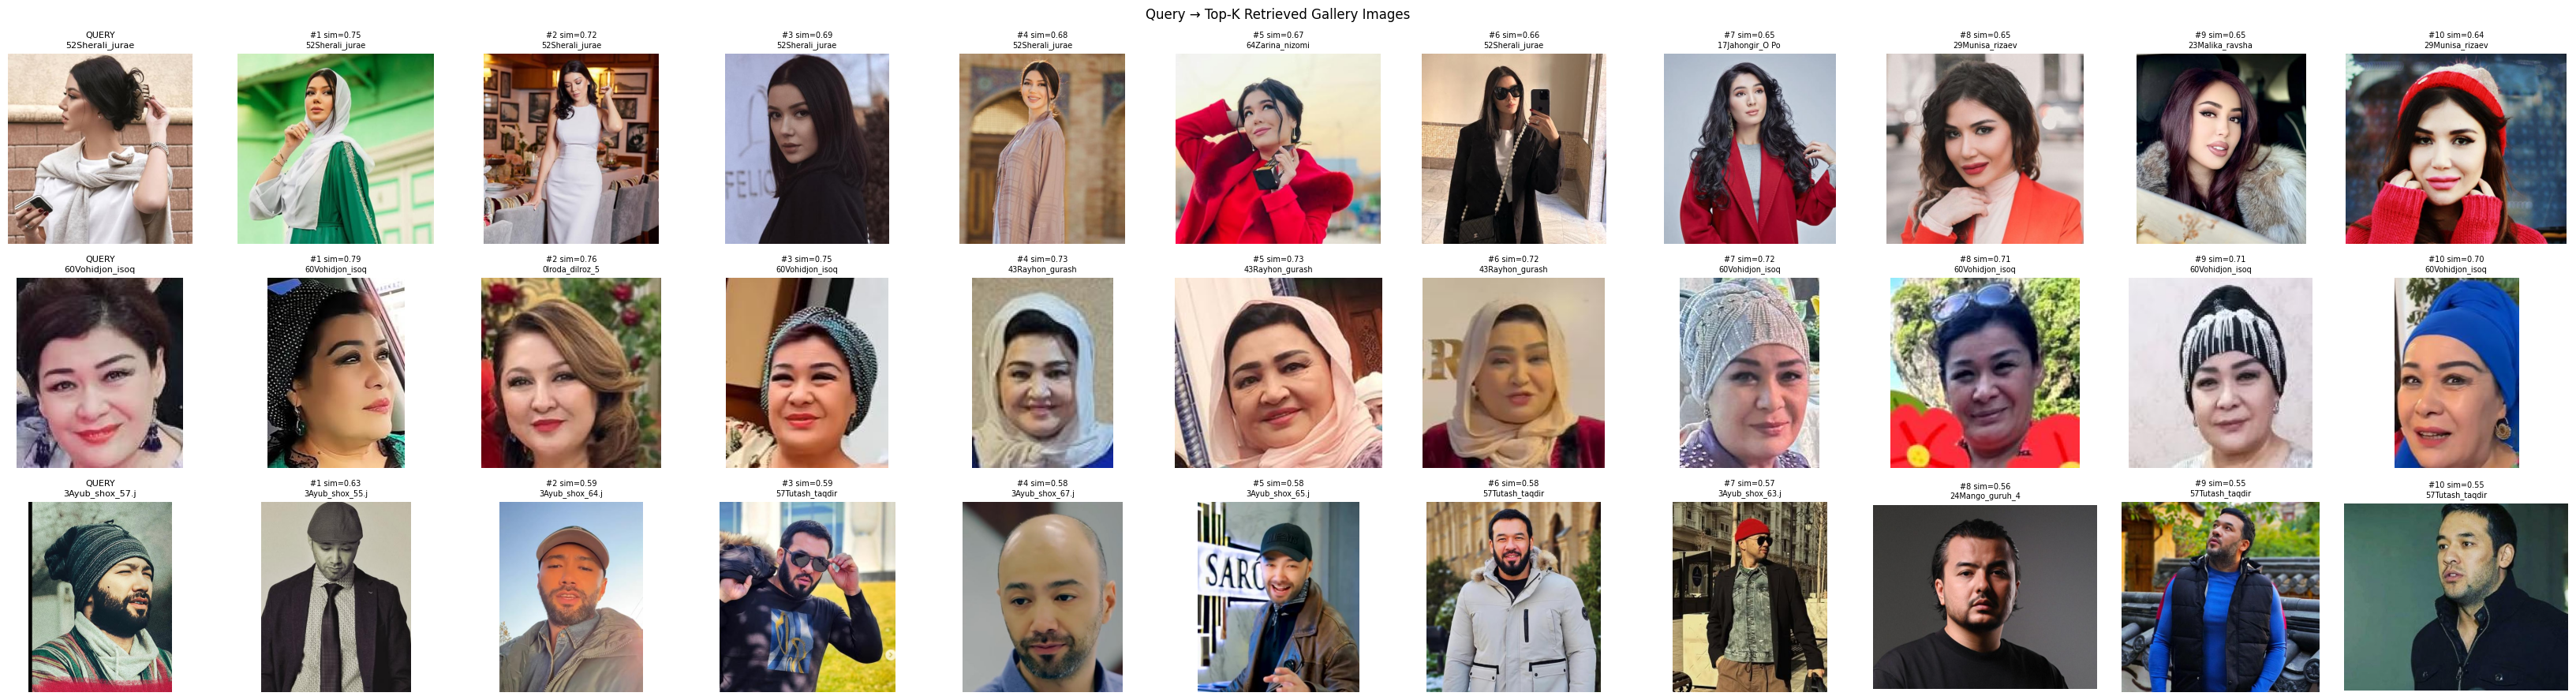

In [31]:
QUERY_DIR   = './test/query'
GALLERY_DIR = './test/gallery'
os.makedirs(QUERY_DIR_TEST,   exist_ok=True)
os.makedirs(GALLERY_DIR_TEST, exist_ok=True)

"""# Clear previous run
for f in os.listdir(QUERY_DIR_TEST):   os.remove(os.path.join(QUERY_DIR_TEST, f))
for f in os.listdir(GALLERY_DIR_TEST): os.remove(os.path.join(GALLERY_DIR_TEST, f))

# Split: 1 image per identity → query, rest → gallery
SOURCE = 'faces_by_identity'
for identity in os.listdir(SOURCE):
    identity_folder = os.path.join(SOURCE, identity)
    images = os.listdir(identity_folder)
    if len(images) < 2:
        continue
    random.shuffle(images)
    shutil.copy(
        os.path.join(identity_folder, images[0]),
        os.path.join(QUERY_DIR_TEST, f'{identity}_{images[0]}')
    )
    for img in images[1:]:
        shutil.copy(
            os.path.join(identity_folder, img),
            os.path.join(GALLERY_DIR_TEST, f'{identity}_{img}')
        )

print(f'Query   : {len(os.listdir(QUERY_DIR_TEST))} images')
print(f'Gallery : {len(os.listdir(GALLERY_DIR_TEST))} images')"""

# Run retrieval
clip_model.eval()
submission = generate_submission(
    QUERY_DIR_TEST, GALLERY_DIR_TEST,
    model=clip_model, preprocess=clip_preprocess, top_k=10
)

# Evaluate accuracy
correct_top1 = 0
correct_top10 = 0
for query_filename, retrieved_list in submission.items():
    query_identity    = '_'.join(query_filename.split('_')[:-1])
    top1_identity     = '_'.join(retrieved_list[0].split('_')[:-1])
    if top1_identity == query_identity:
        correct_top1 += 1
    retrieved_ids = ['_'.join(r.split('_')[:-1]) for r in retrieved_list]
    if query_identity in retrieved_ids:
        correct_top10 += 1

total = len(submission)
print(f'\nTop-1  accuracy : {correct_top1  / total * 100:.2f}%')
print(f'Top-10 accuracy : {correct_top10 / total * 100:.2f}%')

# Visualise 3 random queries
visualise_retrieval(QUERY_DIR_TEST, GALLERY_DIR_TEST,
                    clip_model, clip_preprocess,
                    num_queries=3, top_k=10)

## Cell 10 — Load Best Checkpoint
⚠️ Only run this after a **session reset**.
If you just finished Cell 9 in the same session, skip this and go to Cell 11.

In [ ]:
CKPT_PATH = f'{SAVE_DIR}/best_model.pth'
ckpt = torch.load(CKPT_PATH, map_location=device)
clip_model.load_state_dict(ckpt['clip_state'])
clip_model.eval()
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (Top-1 = {ckpt["top1"]*100:.2f}%)')

## Cell 11 — Generate Exam Submission
Update `QUERY_DIR` and `GALLERY_DIR` with the paths given on exam day.

In [ ]:
# Find your exam folders locally
import os
for root, dirs, files in os.walk('.'):
    for d in dirs:
        print(os.path.join(root, d))

In [46]:
# Step 2: update these paths and run
QUERY_DIR   = './test/query'    # <-- update on exam day
GALLERY_DIR = './test/gallery'  # <-- update on exam day

clip_model.eval()
submission = generate_submission(
    QUERY_DIR, GALLERY_DIR,
    model=clip_model,
    preprocess=clip_preprocess,
    top_k=10
)

print(f'Submission ready: {len(submission)} queries')
print(f'Example: {list(submission.items())[0]}')

# Uncomment to submit:
# submit(submission, 'Your Group Name')

Extracting query embeddings...
Extracting gallery embeddings...
Submission ready: 300 queries
Example: ('b535aa4c3fa886b82028d3d91f77ed8b90984e4c.jpg', ['6ab88e59c494cd5a709eeb046d50fbfbafcc77c1.jpg', 'f16052ea4db70b7488a17d08be78cdbf1a99895b.jpg', 'dd2263fd22847303f3b8e4a36c98e439fd6db338.jpg', '82a829971a058909a4b342b9478eb418fdde400f.jpg', '667b6d39f75f45ae5756c925112948713a2da023.jpg', 'db44d4ad48915444b7a67a7ca502d593cc4237b0.jpg', '17989661aaee70f2890caf79b1b0194dae4edf88.jpg', 'e45686ccb2c5ded2ee1fcfcf7e9a97e64dd71a1d.jpg', 'c7bb0b08313e05b94fe85bac34aae2fcca3a55b3.jpg', '590e48b11bdc3f3895ba8790ccc849133410d87f.jpg'])


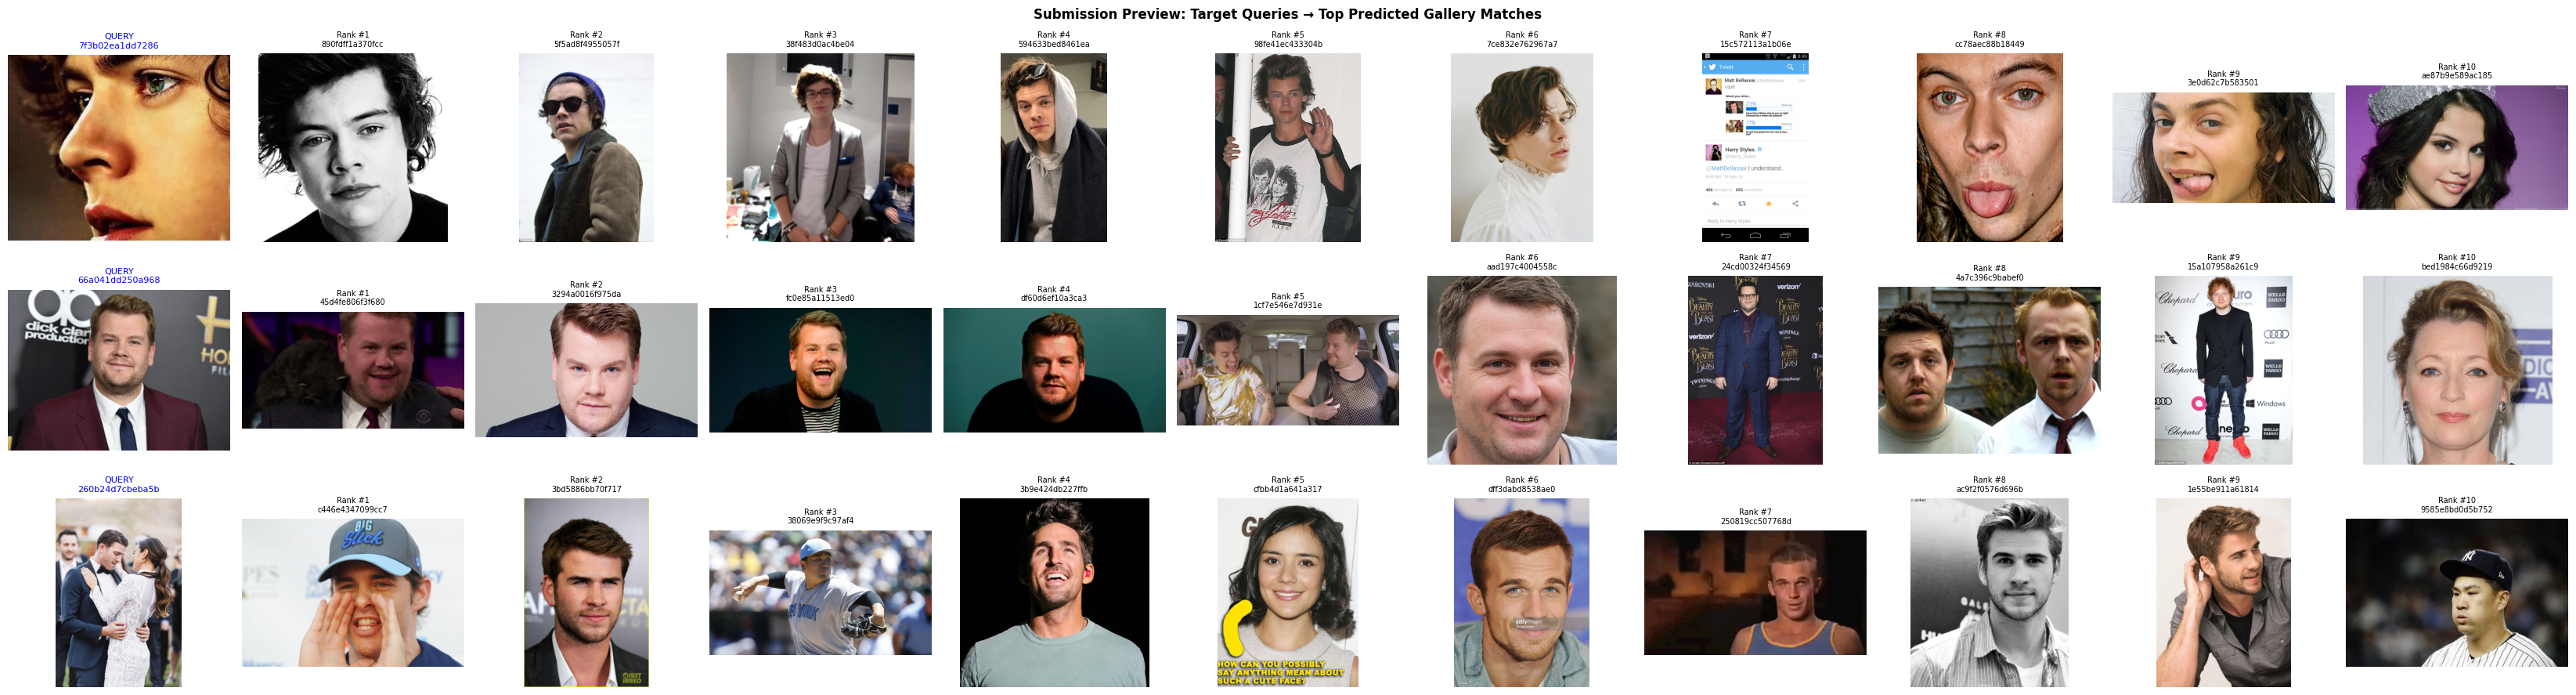

In [47]:
import os
import random
import matplotlib.pyplot as plt
import PIL.Image as PILImage

def visualise_test_submission(query_dir, gallery_dir, submission_dict, num_queries=3, top_k=5):
    """
    Visualises submission dictionary mapping by looking up actual files 
    inside the final query_dir and gallery_dir paths.
    """
    # Pick a few sample queries from the submission dictionary keys
    q_names = list(submission_dict.keys())
    if not q_names:
        print("Submission dictionary is empty! Run the generation block first.")
        return
        
    q_sample = random.sample(q_names, min(num_queries, len(q_names)))

    # Construct plotting grid
    fig, axes = plt.subplots(len(q_sample), top_k + 1,
                             figsize=(3 * (top_k + 1), 3 * len(q_sample)))
    
    # Handle single row formatting edge case
    if num_queries == 1 or len(q_sample) == 1:
        axes = [axes]

    for row, q_name in enumerate(q_sample):
        # 1. Render original test Query image
        q_path = os.path.join(query_dir, q_name)
        if os.path.exists(q_path):
            q_img = PILImage.open(q_path).convert('RGB')
            axes[row][0].imshow(q_img)
        axes[row][0].set_title(f'QUERY\n{q_name[:15]}', fontsize=8, color='blue')
        axes[row][0].axis('off')
        
        # 2. Render ranked predictions returned by the model
        retrieved_list = submission_dict[q_name]
        for col in range(top_k):
            ax = axes[row][col + 1]
            if col < len(retrieved_list):
                g_name = retrieved_list[col]
                g_path = os.path.join(gallery_dir, g_name)
                
                if os.path.exists(g_path):
                    g_img = PILImage.open(g_path).convert('RGB')
                    ax.imshow(g_img)
                ax.set_title(f'Rank #{col+1}\n{g_name[:15]}', fontsize=7)
            ax.axis('off')

    plt.suptitle('Submission Preview: Target Queries → Top Predicted Gallery Matches', fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()

# Run the preview visualization pass using your live active test folders
visualise_test_submission(
    query_dir=QUERY_DIR, 
    gallery_dir=GALLERY_DIR, 
    submission_dict=submission, 
    num_queries=3, 
    top_k=10
)

In [48]:
import json
import requests

In [49]:
def submit(results, groupname, url):
    res = {}
    res['groupname'] = groupname
    res['images'] = results
    res = json.dumps(res)
    # print(res)
    response = requests.post(url, res)
    try:
        result = json.loads(response.text)
        print(f"accuracy is {result['accuracy']}")
    except json.JSONDecodeError:
        print(f"ERROR: {response.text}")


submit(results=submission,groupname="caggol",url="http://videosim.disi.unitn.it:3001/retrieval/")

accuracy is 725.0
